In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score

import matplotlib.pyplot as plt
import numpy as np

In [15]:
np.random.seed(42)

In [29]:
x = np.arange(1, 1001, 1)
x = x.reshape(-1, 1)
x[::100]

array([[  1],
       [101],
       [201],
       [301],
       [401],
       [501],
       [601],
       [701],
       [801],
       [901]])

In [35]:
y = np.pow(x, 2) + np.random.rand(len(x), 1) * x
y[::100]

array([[1.72026792e+00],
       [1.02834390e+04],
       [4.04394491e+04],
       [9.08382708e+04],
       [1.61001114e+05],
       [2.51213671e+05],
       [3.61452436e+05],
       [4.92051458e+05],
       [6.42212656e+05],
       [8.12129940e+05]])

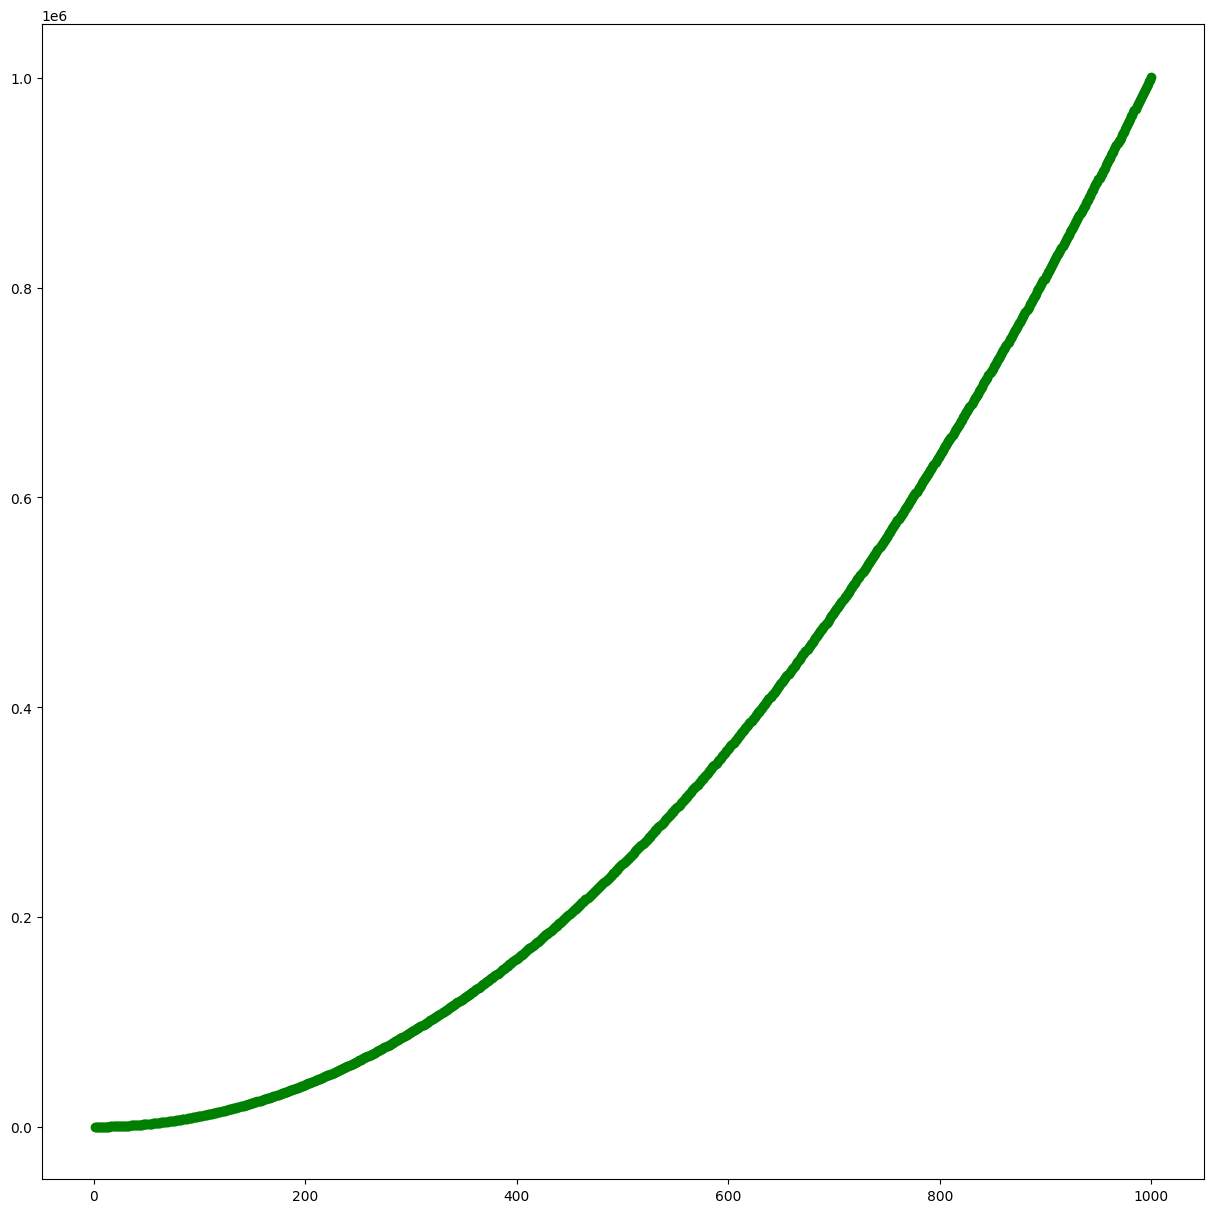

In [41]:
plt.figure(figsize=(15, 15))
plt.scatter(x=x, y=y, color = "g")

In [42]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, shuffle=True)

In [43]:
pln = Pipeline([
    ("polyfeature", PolynomialFeatures(degree=2)),
    ("scaaler", StandardScaler()),
    ("model", LinearRegression())
])

In [44]:
pln.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polyfeature', ...), ('scaaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [46]:
cross_val_score(pln, x_train, y_train)

array([0.99999979, 0.99999971, 0.99999969, 0.99999962, 0.9999997 ])

In [47]:
y_train_pred = pln.predict(x_train)

In [48]:
r2_score(y_train, y_train_pred)

0.9999997063098875

In [49]:
y_test_pred = pln.predict(x_test)

In [50]:
r2_score(y_test, y_test_pred)

0.9999997103964966